In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix ,recall_score , precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score
import pickle

In [8]:
customer=pd.read_csv("customer_processed.csv")

In [9]:
customer.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [10]:
customer.sample(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1249,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,45.05,45.05,Yes
3997,Female,0,Yes,No,69,Yes,No,DSL,No,Yes,No,No,No,Yes,Two year,Yes,Credit card (automatic),61.45,4131.20,No


In [11]:
le=LabelEncoder()

In [12]:
customer['Churn']=le.fit_transform(customer['Churn'])

In [13]:
le.transform(['No'])

array([0])

In [14]:
customer.sample(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2183,Male,0,No,No,2,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),50.20,109.25,0
1126,Male,0,No,No,7,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,74.65,544.55,1


In [15]:
X_train,X_test,y_train,y_test=train_test_split(customer.drop(columns=['Churn']),
                                               customer['Churn'],test_size=0.2)

In [16]:
X_train.shape

(5634, 19)

In [18]:
transformer=ColumnTransformer(transformers=[
    ('ct1',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,categories=[['Month-to-month', 'One year', 'Two year']]),['Contract']),
    ('ct2',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),['gender','Partner','Dependents','PhoneService','PaperlessBilling','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                                   'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod']),
    ('ct3',StandardScaler(),['tenure','MonthlyCharges','TotalCharges'])
],  remainder='passthrough')


In [19]:
X_train.shape

(5634, 19)

In [20]:
lr=LogisticRegression()

In [21]:
pipe1=Pipeline([
    ('p1',transformer),
    ('p2',lr)
])

In [22]:
pipe1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('p1', ...), ('p2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ct1', ...), ('ct2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [23]:
y_pred1=pipe1.predict(X_test)

In [24]:
print("Confusion Matrix for logistic regression model")
print(confusion_matrix(y_test,y_pred1))

Confusion Matrix for logistic regression model
[[914 108]
 [163 224]]


In [25]:
dt=DecisionTreeClassifier()

In [26]:
pipe2=Pipeline([
    ('p1',transformer),
    ('p2',dt)
])

In [27]:
pipe2.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('p1', ...), ('p2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ct1', ...), ('ct2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [28]:
y_pred2=pipe2.predict(X_test)

In [29]:
print("Confusion Matrix for decision tree")
print(confusion_matrix(y_test,y_pred2))

Confusion Matrix for decision tree
[[844 178]
 [187 200]]


In [30]:
print("LogisticRegression:-")
print("Accuracy-",accuracy_score(y_test,y_pred1))

print("Precision-",precision_score(y_test,y_pred1))
print("Recall-",recall_score(y_test,y_pred1))
print("F1_score-",f1_score(y_test,y_pred1))
print("---------------")
print("DecisionTree:-")
print("Accuracy-",accuracy_score(y_test,y_pred2))

print("Precision-",precision_score(y_test,y_pred2))
print("Recall-",recall_score(y_test,y_pred2))
print("F1_score-",f1_score(y_test,y_pred2))

LogisticRegression:-
Accuracy- 0.8076650106458482
Precision- 0.6746987951807228
Recall- 0.5788113695090439
F1_score- 0.6230876216968011
---------------
DecisionTree:-
Accuracy- 0.7409510290986515
Precision- 0.5291005291005291
Recall- 0.5167958656330749
F1_score- 0.5228758169934641


In [31]:
from sklearn.model_selection import cross_val_score
print("LogisticRegression:-")
c1=cross_val_score(pipe1,X_train,y_train,cv=5,scoring='accuracy').mean()
print(c1)

print("DecisionTree:-")
c2=cross_val_score(pipe2,X_train,y_train,cv=5,scoring='accuracy').mean()
print(c2)

LogisticRegression:-
0.8017367978931474
DecisionTree:-
0.7186727838096394


In [32]:
prob1=pipe1.predict_proba(X_test)[:,1]
prob1

array([0.40498998, 0.00738076, 0.62868425, ..., 0.13582701, 0.75452823,
       0.12148072], shape=(1409,))

In [33]:
prob2=pipe2.predict_proba(X_test)[:,1]
prob2

array([0., 0., 1., ..., 0., 1., 0.], shape=(1409,))

In [34]:
lr_auc=roc_auc_score(y_test,prob1)

In [35]:
dt_auc=roc_auc_score(y_test,prob2)

In [36]:
print("pipe1:",lr_auc)
print("pipe2:",dt_auc)


pipe1: 0.8490116658323094
pipe2: 0.6714351451528896


Logisitic Regression model has better AUC score, Cross val score, Accuracy as well as F1 score.

In [37]:
fpr1,tpr1,threshold1=roc_curve(y_test,prob1)
fpr2,tpr2,threshold2=roc_curve(y_test,prob2)


Text(0.5, 1.0, 'ROC Curve Comparision')

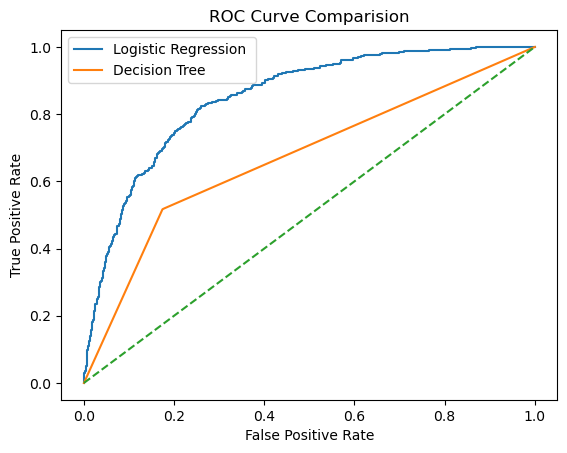

In [38]:
plt.figure()
plt.plot(fpr1,tpr1,label="Logistic Regression ")
plt.plot(fpr2,tpr2,label="Decision Tree")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title('ROC Curve Comparision')

We select model 1 - Logistic Regression

In [ ]:
pickle.dump(pipe1,open('pipe.pkl','wb'))